Now i want to perform SHAP on the model (XGBoost) to find the feature importance per NACE code. This file essentially produces a csv that contains the ***features in importance order for each NACE*** code 

## ***Initials***

In [1]:
!pip install shap

In [2]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt

## ***Help Functions***

In [3]:
def plot_mean_shap_for_naces(shap_per_nace):

    # Plot bar plot for mean SHAP values
    plt.figure(figsize=(12, 8))
    shap_per_nace.plot(kind='bar', stacked=False)
    plt.title("Mean SHAP Values per Feature by NACE Code")
    plt.xlabel("NACE Code")
    plt.ylabel("Mean SHAP Value")
    plt.legend(title="Features", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [20]:
def plot_nace_important_features(nace_code, shap_per_nace, top_n=None):

    # Sort by importance
    sorted_features = shap_per_nace[nace_code].sort_values(ascending=True)
    
    # Select only top_n if requested
    if top_n is not None:
        sorted_features = sorted_features.tail(top_n)

    # Plot
    sorted_features.plot(
        kind="barh", 
        figsize=(8,6), 
        title=f"Top Features for NACE {nace_code}"
    )
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

In [5]:
# function that: plots the most important features across ALL the naces
def plot_important_features(shap_df, X, number):
    mean_shap_importance = shap_df[X.columns].abs().mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    mean_shap_importance.head(number).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title("Global SHAP Feature Importance (Top 15)")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

## ***Load the Data***

In [6]:
df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\7. LLM - Fine Tuning\\1. Fine-Tuning - Inference Datasets Creation\\2. Feature Importance Inspection\\Extracted CSV Files\\ml_model_dataset.csv")
print(df.shape)
print(df.columns)
df.head()

(14688, 30)
Index(['NACE_Code', 'Neighborhood', 'IsTop3', 'Municipal_Community',
       'Centroid_x', 'Centroid_y', 'Neighborhood_Area_km2',
       'distance_to_volos_center_km', 'distance_to_volos_port_km',
       'dist_to_main_road_km', 'dist_to_bus_stop_km', 'dist_to_university_km',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'NACE_Label'],
      dtype='object')


,NACE_Code,Neighborhood,IsTop3,Municipal_Community,Centroid_x,Centroid_y,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,...,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,NACE_Label
0,1.13,Dimini,0,Municipal Community of Dimini,22.882945,39.349112,37.344776,6.154015,5.418577,0.443434,...,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451,0
1,1.13,Xrisi Akti Panagias,0,Municipal Community of Sesklos,22.836899,39.305430,9.983032,11.932475,11.015584,2.299921,...,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725,0
2,1.13,Sesklo,0,Municipal Community of Sesklos,22.838168,39.353051,27.367312,9.814666,9.191001,0.482308,...,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725,0
3,1.13,Agioi Anargiroi,0,Municipal Community of Volos,22.924059,39.366937,0.774436,2.296184,1.978856,0.058142,...,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807,0
4,1.13,Aivaliotika,0,Municipal Community of Volos,22.922660,39.343696,4.848904,3.508166,2.529372,0.224486,...,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807,0


## ***Load the Model***

In [7]:
model = XGBClassifier()
model.load_model("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\7. LLM - Fine Tuning\\1. Fine-Tuning - Inference Datasets Creation\\2. Feature Importance Inspection\\ML Model\\xgb_model.json")

## ***Perfrom SHAP***

### ***Get the SHAP Values***

In [8]:
excluded_cols = ["NACE_Code", "Neighborhood", "Municipal_Community", "IsTop3"]
features = [col for col in df.columns if col not in excluded_cols]

In [9]:
X = df[features] 
print(X.shape)
print(X.columns)
X.head()

(14688, 26)
Index(['Centroid_x', 'Centroid_y', 'Neighborhood_Area_km2',
       'distance_to_volos_center_km', 'distance_to_volos_port_km',
       'dist_to_main_road_km', 'dist_to_bus_stop_km', 'dist_to_university_km',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'NACE_Label'],
      dtype='object')


,Centroid_x,Centroid_y,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km,Population,Άγαμοι_pct,...,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,NACE_Label
0,22.882945,39.349112,37.344776,6.154015,5.418577,0.443434,1.569912,4.273031,2101,0.3889,...,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451,0
1,22.836899,39.305430,9.983032,11.932475,11.015584,2.299921,2.410375,10.100771,899,0.3960,...,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725,0
2,22.838168,39.353051,27.367312,9.814666,9.191001,0.482308,4.965561,7.989610,899,0.3960,...,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725,0
3,22.924059,39.366937,0.774436,2.296184,1.978856,0.058142,0.063879,0.866021,85806,0.4032,...,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807,0
4,22.922660,39.343696,4.848904,3.508166,2.529372,0.224486,0.246542,1.913456,85806,0.4032,...,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807,0


In [10]:
nace_codes = df["NACE_Code"]
print(nace_codes.shape)
print(nace_codes.name)
nace_codes.head()

(14688,)
NACE_Code


0    1.13
1    1.13
2    1.13
3    1.13
4    1.13
Name: NACE_Code, dtype: float64

In [11]:
# perform SHAP on the features of the training set only!
explainer = shap.Explainer(model)
shap_values = explainer(X)

In [12]:
# Convert SHAP values to a DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=X.columns)

# Attach NACE_Code from the original data
shap_df["NACE_Code"] = df["NACE_Code"].values

In [13]:
print(shap_df.shape)
print(shap_df.columns)
shap_df.head()

(14688, 27)
Index(['Centroid_x', 'Centroid_y', 'Neighborhood_Area_km2',
       'distance_to_volos_center_km', 'distance_to_volos_port_km',
       'dist_to_main_road_km', 'dist_to_bus_stop_km', 'dist_to_university_km',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'NACE_Label', 'NACE_Code'],
      dtype='object')


,Centroid_x,Centroid_y,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km,Population,Άγαμοι_pct,...,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,NACE_Label,NACE_Code
0,-0.419889,0.112863,-0.015915,0.000909,0.005765,-0.971351,-0.163665,-0.519772,0.919087,0.002505,...,0.010604,-0.012751,-0.010687,0.008993,-0.001046,0.001472,-0.197103,-0.002927,0.026722,1.13
1,-0.227088,-0.098035,-0.267472,0.059358,-0.374776,-1.856912,-1.730159,-1.177378,-2.168923,0.006380,...,-0.551720,-0.100604,0.049476,-0.118134,-0.001046,0.001769,-0.510273,0.000851,-0.382441,1.13
2,-0.300629,-0.001467,-0.258006,0.060280,-0.368934,-0.991712,-1.596416,-1.140932,-2.872154,0.006380,...,-0.689710,-0.097061,0.049626,-0.118134,-0.001046,0.001770,-0.523004,0.004975,-0.561991,1.13
3,0.357338,0.293414,0.247893,0.007013,-0.132056,0.152540,0.024483,0.828890,0.312461,0.002223,...,0.007272,-0.006242,0.000126,0.018311,-0.001046,-0.002103,0.003197,-0.000537,0.013778,1.13
4,-0.232253,-0.256236,-0.366980,0.015671,0.360351,-0.976605,-0.268017,-0.339886,0.482408,0.002223,...,-0.002794,-0.010048,0.000468,0.016328,-0.001046,-0.003879,0.004002,-0.001315,0.203406,1.13


### ***Save the SHAP Values***

In [69]:
shap_df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\7. LLM - Fine Tuning\\1. Fine-Tuning - Inference Datasets Creation\\2. Feature Importance Inspection\\Extracted CSV Files\\shap_values.csv", index=False)

### ***Group the SHAP Values per NACE***

In [14]:
shap_df_abs = shap_df[X.columns].abs()

In [15]:
shap_df_abs["NACE_Code"] = df["NACE_Code"]

In [16]:
print(shap_df_abs.shape)
print(shap_df_abs.columns)
shap_df_abs.head()

(14688, 27)
Index(['Centroid_x', 'Centroid_y', 'Neighborhood_Area_km2',
       'distance_to_volos_center_km', 'distance_to_volos_port_km',
       'dist_to_main_road_km', 'dist_to_bus_stop_km', 'dist_to_university_km',
       'Population', 'Άγαμοι_pct', 'Έγγαμοι_pct', 'Χήροι_pct',
       'Διαζευγμένοι_pct', 'age_0_14_pct', 'age_15_64_pct', 'age_65_plus_pct',
       'low_education_pct', 'medium_education_pct', 'high_education_pct',
       'unemployment_rate', 'labor_force_participation_rate',
       'primary_sector_pct', 'secondary_sector_pct', 'tertiary_sector_pct',
       'Area_km2', 'NACE_Label', 'NACE_Code'],
      dtype='object')


,Centroid_x,Centroid_y,Neighborhood_Area_km2,distance_to_volos_center_km,distance_to_volos_port_km,dist_to_main_road_km,dist_to_bus_stop_km,dist_to_university_km,Population,Άγαμοι_pct,...,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2,NACE_Label,NACE_Code
0,0.419889,0.112863,0.015915,0.000909,0.005765,0.971351,0.163665,0.519772,0.919087,0.002505,...,0.010604,0.012751,0.010687,0.008993,0.001046,0.001472,0.197103,0.002927,0.026722,1.13
1,0.227088,0.098035,0.267472,0.059358,0.374776,1.856912,1.730159,1.177378,2.168923,0.006380,...,0.551720,0.100604,0.049476,0.118134,0.001046,0.001769,0.510273,0.000851,0.382441,1.13
2,0.300629,0.001467,0.258006,0.060280,0.368934,0.991712,1.596416,1.140932,2.872154,0.006380,...,0.689710,0.097061,0.049626,0.118134,0.001046,0.001770,0.523004,0.004975,0.561991,1.13
3,0.357338,0.293414,0.247893,0.007013,0.132056,0.152540,0.024483,0.828890,0.312461,0.002223,...,0.007272,0.006242,0.000126,0.018311,0.001046,0.002103,0.003197,0.000537,0.013778,1.13
4,0.232253,0.256236,0.366980,0.015671,0.360351,0.976605,0.268017,0.339886,0.482408,0.002223,...,0.002794,0.010048,0.000468,0.016328,0.001046,0.003879,0.004002,0.001315,0.203406,1.13


In [17]:
shap_per_nace = shap_df_abs.groupby("NACE_Code").mean().T

In [18]:
print(shap_per_nace.shape)
print(shap_per_nace.columns)
shap_per_nace.head()

(26, 306)
Index([ 1.13,   1.3,  1.49,  1.61,   2.4,  3.11,  3.22,  8.11, 10.11, 10.13,
       ...
       95.12, 95.21, 95.24, 95.29, 96.01, 96.02, 96.03, 96.04, 96.09,  97.0],
      dtype='float64', name='NACE_Code', length=306)


NACE_Code,1.13,1.30,1.49,1.61,2.40,3.11,3.22,8.11,10.11,10.13,...,95.12,95.21,95.24,95.29,96.01,96.02,96.03,96.04,96.09,97.00
Centroid_x,0.227821,0.227821,0.294568,0.325449,0.200854,0.241105,0.626068,0.646251,0.646251,0.481554,...,0.403723,0.403723,0.412269,0.412269,0.417266,0.413570,0.408826,0.405690,0.405690,0.405690
Centroid_y,0.284977,0.284977,0.297675,0.312303,0.252482,0.252482,0.263794,0.264853,0.264853,0.322679,...,0.257482,0.244845,0.268974,0.268974,0.237717,0.251702,0.241263,0.256380,0.256380,0.256380
Neighborhood_Area_km2,0.236942,0.236942,0.168978,0.183681,0.196733,0.172223,0.245732,0.207206,0.207206,0.239424,...,0.574603,0.629157,0.194426,0.194426,0.213286,0.160361,0.149571,0.299624,0.299624,0.299624
distance_to_volos_center_km,0.060564,0.060564,0.088407,0.098277,0.184101,0.148409,0.113710,0.120423,0.120423,0.150621,...,0.053696,0.060848,0.144978,0.144978,0.089455,0.054142,0.054142,0.150736,0.150736,0.150736
distance_to_volos_port_km,0.237146,0.237146,0.276217,0.364778,0.411363,0.508899,0.263145,0.339553,0.339553,0.222780,...,0.284442,0.265664,0.264383,0.264383,0.349909,0.430446,0.370647,0.862625,0.862625,0.862625


### ***Save the SHAP Values per NACE***

In [75]:
shap_per_nace.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\7. LLM - Fine Tuning\\1. Fine-Tuning - Inference Datasets Creation\\2. Feature Importance Inspection\\Extracted CSV Files\\shap_values_per_nace.csv", index=False)

## ***Evaluate the SHAP Values***

### ***Feature Importance of All NACE codes***

The summary plot is about ***all the NACE codes***, so here we see the most important features across all the data. This is like an average

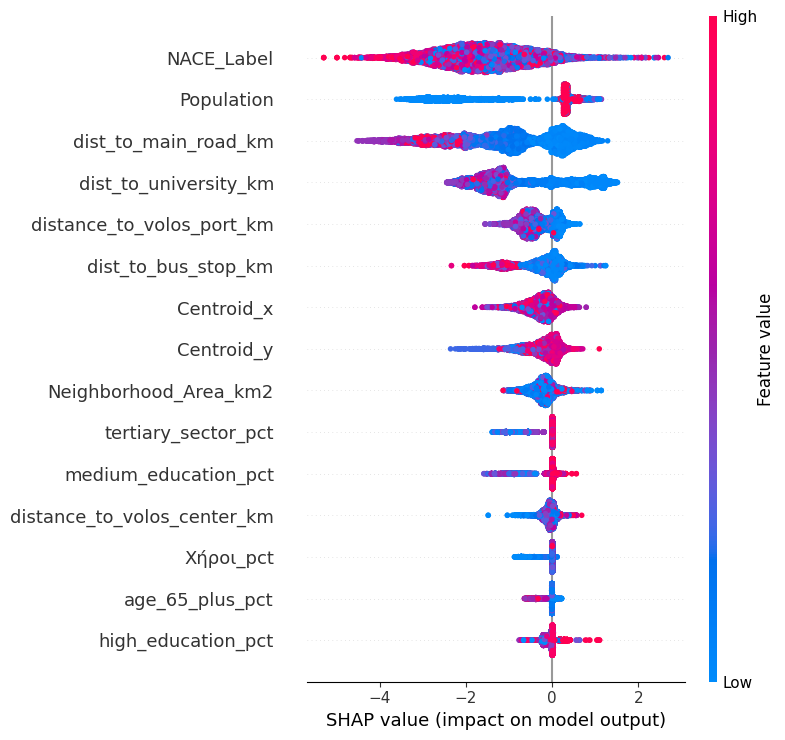

In [19]:
shap.summary_plot(shap_values.values, X, feature_names=X.columns, max_display=15)

The following plot gives the same results as the above, found by using the mean values of the SHAP values

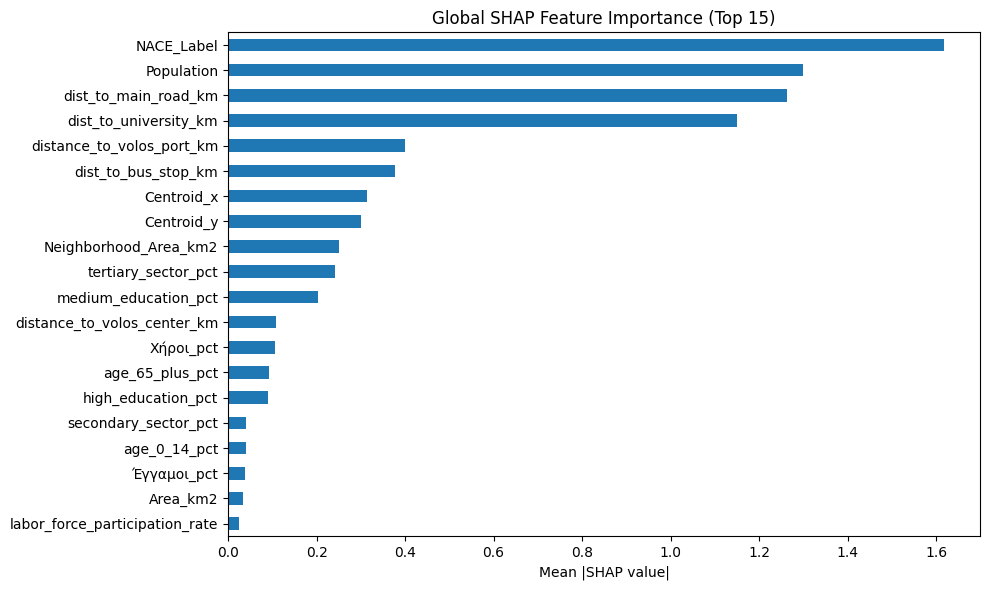

In [84]:
plot_important_features(shap_df, X, number=20)

C:\Users\Giorgos\AppData\Local\Temp\ipykernel_8984\41885422.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

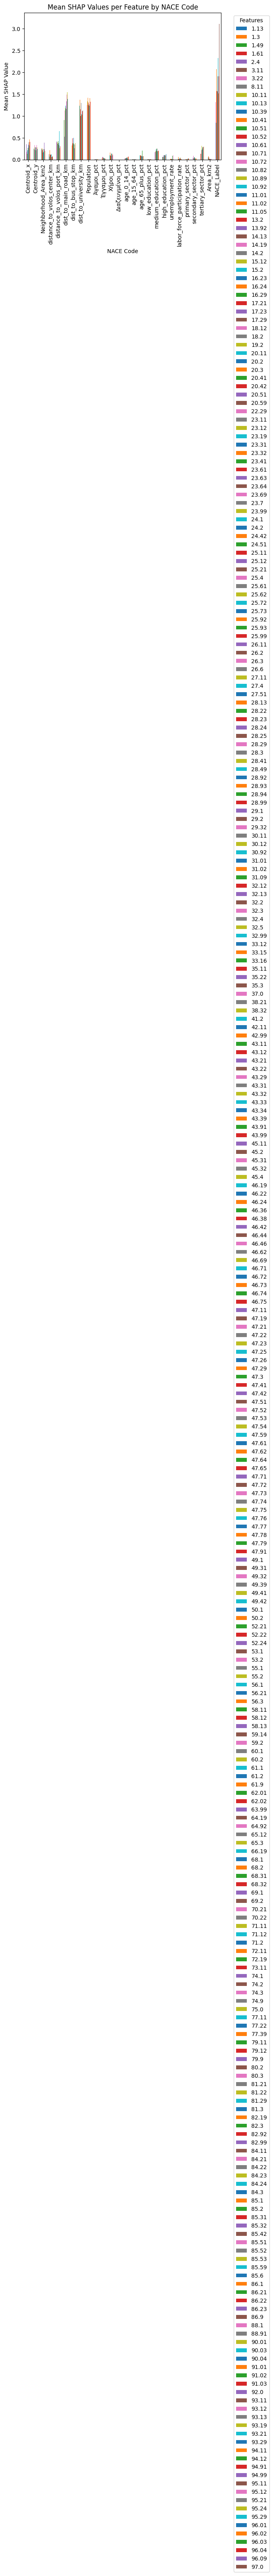

In [98]:
plot_mean_shap_for_naces(shap_per_nace)

### ***Feature Importance of Specific NACE codes***

For a specific NACE code: we can see its most important features based on the SHAP values:

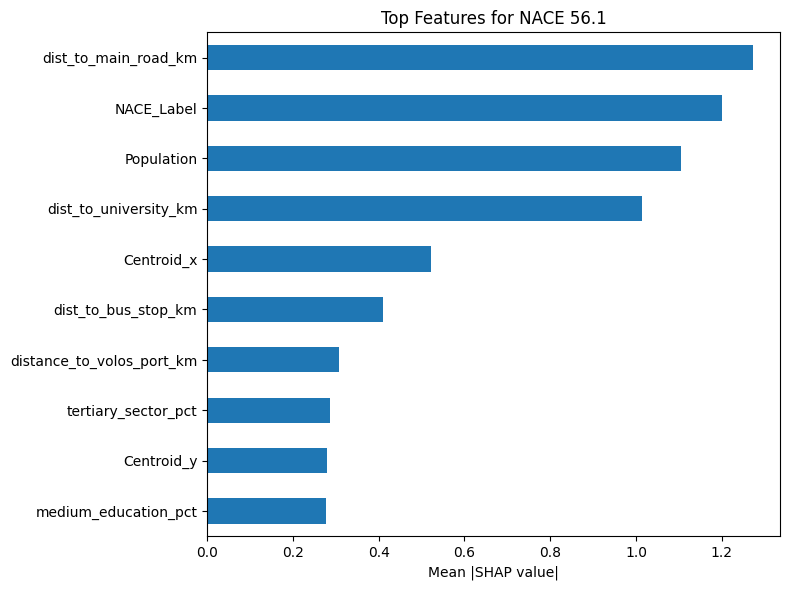

In [21]:
plot_nace_important_features(shap_per_nace=shap_per_nace, nace_code=56.1, top_n=10)

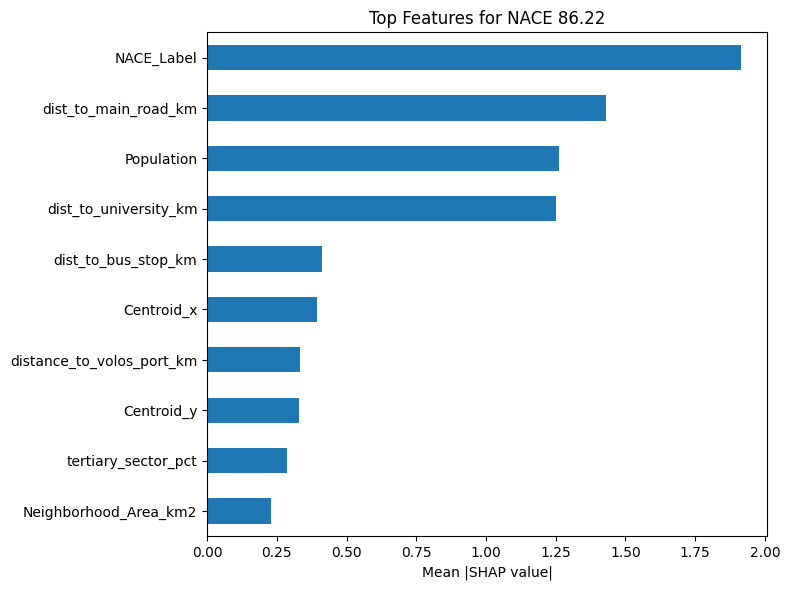

In [22]:
plot_nace_important_features(shap_per_nace=shap_per_nace, nace_code=86.22, top_n=10)

## ***Save the Feature Importances***

In order to use them later in the prompt of the Fine-Tuning dataset, I will save the features in importance order:

In [109]:
rows = []

for nace, group in shap_df.groupby("NACE_Code"):
    mean_shap = group[X.columns].abs().mean().sort_values(ascending=False)
    top_features = list(mean_shap.index)  # all features sorted by SHAP
    
    row = {"NACE_Code": nace}
    for i, feat in enumerate(top_features, 1):
        row[f"Feature_{i}"] = feat
    
    rows.append(row)

# Convert to DataFrame and save
ranked_features_df = pd.DataFrame(rows)

In [110]:
ranked_features_df.head()

,NACE_Code,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26
0,1.13,Population,dist_to_main_road_km,dist_to_university_km,NACE_Label,dist_to_bus_stop_km,Centroid_y,distance_to_volos_port_km,Neighborhood_Area_km2,Centroid_x,...,high_education_pct,Area_km2,secondary_sector_pct,labor_force_participation_rate,unemployment_rate,age_0_14_pct,Άγαμοι_pct,primary_sector_pct,low_education_pct,Διαζευγμένοι_pct
1,1.30,Population,dist_to_main_road_km,dist_to_university_km,NACE_Label,dist_to_bus_stop_km,Centroid_y,distance_to_volos_port_km,Neighborhood_Area_km2,Centroid_x,...,high_education_pct,Area_km2,secondary_sector_pct,labor_force_participation_rate,unemployment_rate,age_0_14_pct,Άγαμοι_pct,primary_sector_pct,low_education_pct,Διαζευγμένοι_pct
2,1.49,NACE_Label,Population,dist_to_main_road_km,dist_to_university_km,dist_to_bus_stop_km,Centroid_y,Centroid_x,distance_to_volos_port_km,medium_education_pct,...,labor_force_participation_rate,high_education_pct,Area_km2,secondary_sector_pct,age_0_14_pct,unemployment_rate,Άγαμοι_pct,primary_sector_pct,low_education_pct,Διαζευγμένοι_pct
3,1.61,Population,NACE_Label,dist_to_main_road_km,dist_to_university_km,dist_to_bus_stop_km,distance_to_volos_port_km,Centroid_x,Centroid_y,medium_education_pct,...,labor_force_participation_rate,high_education_pct,Area_km2,secondary_sector_pct,age_0_14_pct,unemployment_rate,Άγαμοι_pct,primary_sector_pct,low_education_pct,Διαζευγμένοι_pct
4,2.40,NACE_Label,Population,dist_to_main_road_km,dist_to_university_km,distance_to_volos_port_km,dist_to_bus_stop_km,Centroid_y,Centroid_x,Neighborhood_Area_km2,...,Area_km2,secondary_sector_pct,age_0_14_pct,labor_force_participation_rate,unemployment_rate,Άγαμοι_pct,primary_sector_pct,age_15_64_pct,low_education_pct,Διαζευγμένοι_pct


In [112]:
ranked_features_df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\7. LLM - Fine Tuning\\1. Fine-Tuning - Inference Datasets Creation\\2. Feature Importance Inspection\\Extracted CSV Files\\feature_importance_rankings_per_nace.csv", index=False)